<a href="https://colab.research.google.com/github/pranalishende/classification-animal/blob/main/classification_of_animal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from PIL import Image
import numpy as np

# Define the base input and output folders
base_input_folder = '/content/animal-classification'
base_output_folder = '/content/outputImg'

# Define the subfolders to process
subfolders = ['classification of animal']

# Target size for resizing
target_size = (250, 250)

# Create base folders if they don't exist
os.makedirs(base_input_folder, exist_ok=True)
os.makedirs(base_output_folder, exist_ok=True)

print(f"Base input folder: {base_input_folder}")
print(f"Base output folder: {base_output_folder}")
print(f"Subfolders to process: {subfolders}")

Base input folder: /content/animal-classification
Base output folder: /content/outputImg
Subfolders to process: ['classification of animal']


In [ ]:
for subfolder_name in subfolders:
    input_subfolder_path = os.path.join(base_input_folder, subfolder_name)
    os.makedirs(input_subfolder_path, exist_ok=True)

    if not os.listdir(input_subfolder_path):
        print(f"Input subfolder '{input_subfolder_path}' is empty. Creating a dummy image.")
        dummy_image_path = os.path.join(input_subfolder_path, f'dummy_{subfolder_name}_data.png')
        dummy_image = Image.fromarray(np.uint8(np.random.rand(100, 100, 3) * 255))
        dummy_image.save(dummy_image_path)
        print(f"Created: {dummy_image_path}")
    else:
        print(f"Input subfolder '{input_subfolder_path}' is not empty. Skipping dummy data creation.")


Input subfolder '/content/animal-classification/classification of animal' is empty. Creating a dummy image.
Created: /content/animal-classification/classification of animal/dummy_classification of animal_data.png



Processing images in: /content/animal-classification/classification of animal
  Resized 'dummy_classification of animal_data.png' and saved to '/content/outputImg/classification of animal'.

Successfully processed a total of 1 image(s).

Displaying one of the resized images:


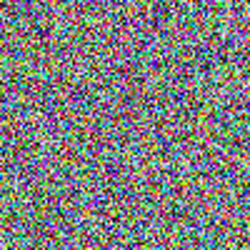

In [ ]:
image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')
overall_processed_count = 0

for subfolder_name in subfolders:
    input_subfolder_path = os.path.join(base_input_folder, subfolder_name)
    output_subfolder_path = os.path.join(base_output_folder, subfolder_name)

    os.makedirs(output_subfolder_path, exist_ok=True)

    print(f"\nProcessing images in: {input_subfolder_path}")
    processed_in_subfolder = 0
    for filename in os.listdir(input_subfolder_path):
        if filename.lower().endswith(image_extensions):
            input_path = os.path.join(input_subfolder_path, filename)
            output_path = os.path.join(output_subfolder_path, filename)

            try:
                with Image.open(input_path) as img:
                    resized_img = img.resize(target_size)
                    resized_img.save(output_path)
                    processed_in_subfolder += 1
                    overall_processed_count += 1
                    print(f"  Resized '{filename}' and saved to '{output_subfolder_path}'.")
            except Exception as e:
                print(f"  Error processing '{filename}': {e}")
    if processed_in_subfolder == 0:
              print(f"  No image files found or processed in '{input_subfolder_path}'.")

if overall_processed_count == 0:
    print("\nNo image files were processed across all specified subfolders.")
else:
    print(f"\nSuccessfully processed a total of {overall_processed_count} image(s).")

# Optional: Display one of the resized images from the first output subfolder to verify
if overall_processed_count > 0 and len(os.listdir(os.path.join(base_output_folder, subfolders[0]))) > 0:
    print("\nDisplaying one of the resized images:")
    first_output_subfolder = os.path.join(base_output_folder, subfolders[0])
    first_resized_image = os.listdir(first_output_subfolder)[0]
    display(Image.open(os.path.join(first_output_subfolder, first_resized_image)))



In [ ]:
# Install torchvision if not already installed
try:
    import torchvision
    print("torchvision is already installed.")
except ImportError:
    print("torchvision not found, installing...")
    !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 # or cpu
    import torchvision
    print("torchvision installed successfully.")


torchvision is already installed.


In [ ]:
import torchvision.transforms as transforms

# Define the base input folder for augmentation (the output from previous step)
base_augmentation_input_folder = base_output_folder # /content/outputImg
# Define the base output folder for augmented images
base_augmentation_output_folder = '/content/augmented_outputImg'

os.makedirs(base_augmentation_output_folder, exist_ok=True)

print(f"Base input folder for augmentation: {base_augmentation_input_folder}")
print(f"Base output folder for augmented images: {base_augmentation_output_folder}")

# Define augmentation transformations
# These transformations will be applied to each image
augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # Randomly flip the image horizontally
    transforms.RandomRotation(degrees=15),   # Randomly rotate by up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2), # Randomly change brightness, contrast, saturation, and hue
    # transforms.ToTensor() # Convert PIL Image to PyTorch Tensor (not needed if we save as PIL)
])

# Number of augmented images to generate per original image
num_augmentations_per_image = 3 # Generate 3 augmented versions for each original image



Base input folder for augmentation: /content/outputImg
Base output folder for augmented images: /content/augmented_outputImg



Augmenting images in: /content/outputImg/classification of animal
  Augmented 'dummy_classification of animal_data.png' to 'dummy_classification of animal_data_aug0.png' and saved.
  Augmented 'dummy_classification of animal_data.png' to 'dummy_classification of animal_data_aug1.png' and saved.
  Augmented 'dummy_classification of animal_data.png' to 'dummy_classification of animal_data_aug2.png' and saved.

Successfully generated a total of 3 augmented image(s).

Displaying one of the augmented images:


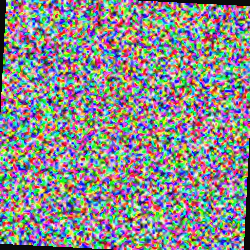

In [ ]:
augmented_count = 0

for subfolder_name in subfolders:
    input_subfolder_path = os.path.join(base_augmentation_input_folder, subfolder_name)
    output_subfolder_path = os.path.join(base_augmentation_output_folder, subfolder_name)

    os.makedirs(output_subfolder_path, exist_ok=True)

    print(f"\nAugmenting images in: {input_subfolder_path}")

    # Check if the input subfolder actually exists and has images
    if not os.path.exists(input_subfolder_path) or not os.listdir(input_subfolder_path):
        print(f"  Input subfolder '{input_subfolder_path}' is empty or does not exist. Skipping augmentation for this subfolder.")
        continue

    for filename in os.listdir(input_subfolder_path):
        if filename.lower().endswith(image_extensions):
            original_image_path = os.path.join(input_subfolder_path, filename)

            try:
                with Image.open(original_image_path) as img:
                    for i in range(num_augmentations_per_image):
                        augmented_img = augmentation_transforms(img)

                        # Create a unique filename for each augmented image
                        name, ext = os.path.splitext(filename)
                        augmented_filename = f"{name}_aug{i}{ext}"
                        augmented_output_path = os.path.join(output_subfolder_path, augmented_filename)
                        augmented_img.save(augmented_output_path)
                        augmented_count += 1
                        print(f"  Augmented '{filename}' to '{augmented_filename}' and saved.")
            except Exception as e:
                print(f"  Error augmenting '{filename}': {e}")

if augmented_count == 0:
    print("\nNo images were augmented across all specified subfolders.")
else:
    print(f"\nSuccessfully generated a total of {augmented_count} augmented image(s).")

# Optional: Display one of the augmented images from the first output subfolder to verify
if augmented_count > 0 and len(os.listdir(os.path.join(base_augmentation_output_folder, subfolders[0]))) > 0:
    print("\nDisplaying one of the augmented images:")
    first_augmented_subfolder = os.path.join(base_augmentation_output_folder, subfolders[0])
    first_augmented_image = os.listdir(first_augmented_subfolder)[0]
    display(Image.open(os.path.join(first_augmented_subfolder, first_augmented_image)))

